In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

In [104]:
df.to_csv('cleaned_spotify.csv', index=False)
df = pd.read_csv('cleaned_spotify.csv')

In [105]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [114]:
df_test = df.drop(columns = ["Unnamed: 0", "track_id", "artists", "album_name", "track_name", "explicit", "mode", "track_genre"])
df_test

,popularity,duration_ms,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0.676,0.4610,1,-6.746,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,55,149610,0.420,0.1660,1,-17.235,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,57,210826,0.438,0.3590,0,-9.734,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,71,201933,0.266,0.0596,0,-18.515,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,82,198853,0.618,0.4430,2,-9.681,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,0.172,0.2350,5,-16.393,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113996,22,385000,0.174,0.1170,0,-18.318,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113997,22,271466,0.629,0.3290,0,-10.895,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113998,41,283893,0.587,0.5060,7,-10.889,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [115]:
df_test["popularity_bins"] = pd.qcut(df_test["popularity"], q = 3, labels=[0, 1, 2])

In [142]:
# PCA testing all numerical features
X = df_test.drop(columns = ["popularity", "popularity_bins"], axis = 1).values   
y = df_test["popularity_bins"].values             

# Train-test split
X_train, X_temp, y_train, y_temp  = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42)
                                                    
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Find k
pca_initial = PCA(n_components = None)
pca_initial.fit(X_train_scaled)

evr = pca.explained_variance_ratio_
cumulative = np.cumsum(evr)
print(evr)
print()
print(cumulative)

k = np.argmax(cumulative >= 0.80) + 1
print(f"Components needed for 80% variance: {k}")

# PCA with our found k 
pca_final = PCA(n_components = k)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_val_pca = pca_final.transform(X_val_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print(f"Variance retained with new k: {evr.sum()*100:.1f}%")

[0.22769577 0.11894394 0.09705778 0.08328588 0.07667126 0.07444822
 0.06859671 0.06427493]

[0.22769577 0.34663971 0.44369749 0.52698337 0.60365463 0.67810286
 0.74669957 0.8109745 ]
Components needed for 80% variance: 8
Variance retained with new k: 81.1%


In [119]:
# Logistic regression (SCRAP, attempted to add bins to make it higher but did not push it over)
model = LogisticRegression(random_state = 42, max_iter = 100)
model.fit(X_train_pca, y_train)

print(f"Train accuracy: {model.score(X_train_pca, y_train)*100:.2f}%")
print(f"Val accuracy: {model.score(X_val_pca, y_train)*100:.2f}%")
print(f"Test  accuracy: {model.score(X_test_pca,  y_test)*100:.2f}%")

Train accuracy: 39.49%


ValueError: Found input variables with inconsistent numbers of samples: [91200, 11400]

I attempted to do logistic regression, but the train, validation, and test accuracies were too low. For example, the train score was 14% and 39.09% after I added the bin categories for popularity. 

In [143]:
# Random Forest Classifier 
model = RandomForestClassifier(n_estimators = 500, max_depth = 13, random_state = 42, class_weight = "balanced")
model.fit(X_train_pca, y_train)

# Accuracy and AUC
results = []
for name, X_set, y_true in [("Train", X_train_pca, y_train), 
                                ("Val", X_val_pca, y_val), 
                                ("Test", X_test_pca, y_test)]:
    
    preds = model.predict(X_set)
    probs = model.predict_proba(X_set)
    
    acc = accuracy_score(y_true, preds)
    auc = roc_auc_score(y_true, probs, multi_class = "ovr", average = "macro")
    
    results.append({"Split": name, "Accuracy": f"{acc*100:.2f}%", "AUC": round(auc, 4)})

# 7. Final Output
print("\n--- Final Model Performance ---")
print(pd.DataFrame(results).to_string(index = False))


--- Final Model Performance ---
Split Accuracy    AUC
Train   66.80% 0.8401
  Val   53.49% 0.7279
 Test   54.28% 0.7291


Scores are near each other, no overfitting

In [144]:
# Rank the components by how much they helped the model
importances = pd.Series(model.feature_importances_, index = [f"PC{i+1}" for i in range(8)])
print(importances.sort_values(ascending = False))

PC1    0.146384
PC3    0.143612
PC7    0.138507
PC2    0.136887
PC8    0.127799
PC6    0.111090
PC4    0.100086
PC5    0.095635
dtype: float64


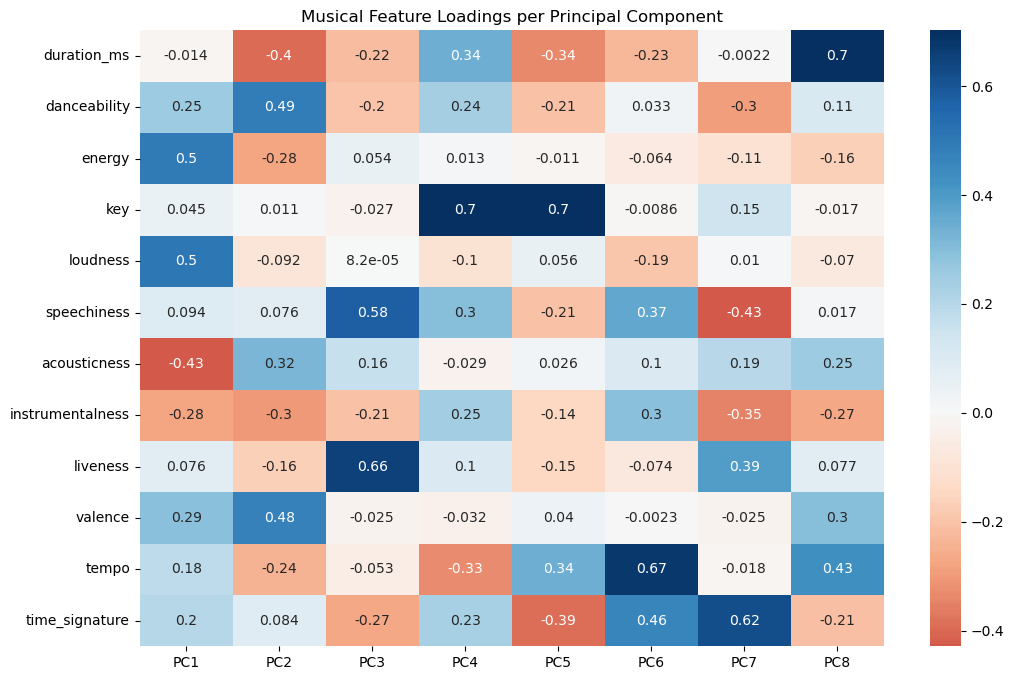

In [145]:
feature_names = df_test.drop(columns = ["popularity", "popularity_bins"]).columns
loadings = pd.DataFrame(pca_final.components_.T, index = feature_names, columns = [f"PC{i+1}" for i in range(k)])

# Heatmap
plt.figure(figsize = (12, 8))
sns.heatmap(loadings, annot = True, cmap = "RdBu", center=0)
plt.title('Musical Feature Loadings per Principal Component')
plt.show()

In [146]:
# Apply min-max scaling to normalize tempo
df["loudness_norm"] = (df["loudness"] - df["loudness"].min()) / (df["loudness"].max() - df["loudness"].min())
df["duration_norm"] = (df["duration_ms"] - df["duration_ms"].min()) / (df["duration_ms"].max() - df["duration_ms"].min())

In [147]:
# Create our own formula to determine what we define as catchy based on the features from the heatmap (take the highest correlation)
df["catchiness_score"] = (df["danceability"] * 0.49) + (df["energy"] * 0.5) + (df["valence"] * 0.48) + (df["loudness_norm"] * 0.5) - (df["acousticness"] * 0.43) - (df["duration_norm"] * 0.43)

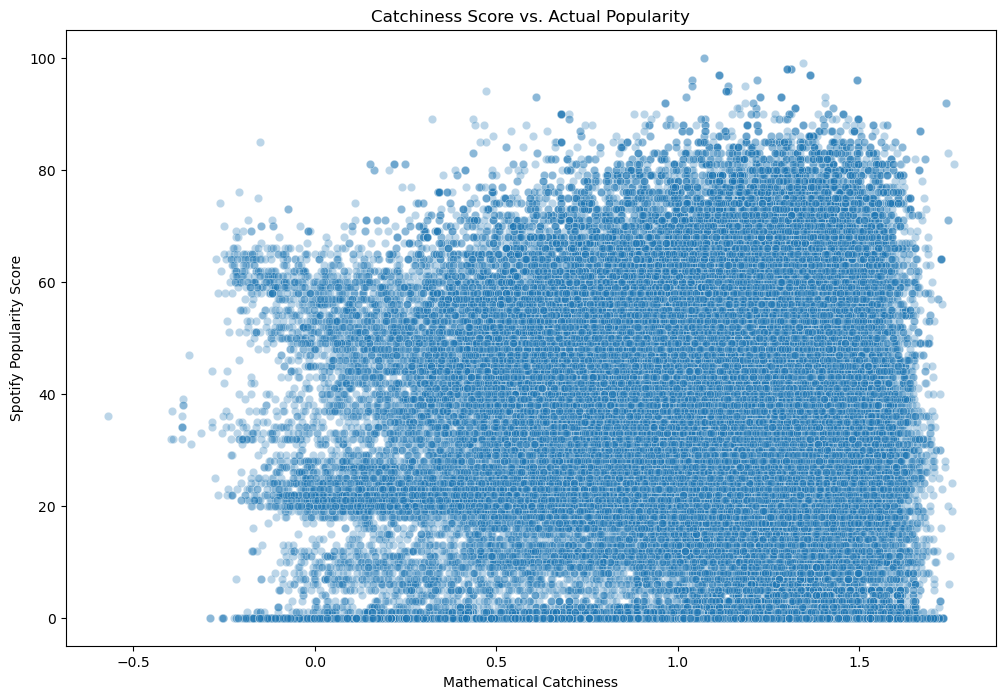

In [148]:
# Visualization: Catchiness vs. Popularity
plt.figure(figsize = (12, 8))
sns.scatterplot(data = df, x = "catchiness_score", y = "popularity", alpha = 0.3)
plt.title('Catchiness Score vs. Actual Popularity')
plt.xlabel('Mathematical Catchiness')
plt.ylabel('Spotify Popularity Score')
plt.show()

Right leaning => High catchiness seems to be a requirement for popular songs

In [138]:
correlation = df['catchiness_score'].corr(df['popularity'])
print(f"Correlation with Popularity: {correlation:.4f}")

Correlation with Popularity: 0.0111


In [140]:
df[df['track_genre'] == 'pop']['catchiness_score'].corr(df['popularity'])

np.float64(0.0034486934878899442)

In [141]:
df[df['track_genre'] == 'acoustic']['catchiness_score'].corr(df['popularity'])

np.float64(0.1612520567921595)